# Estatísticas Gerais do Desafio de Filmes 2026

## 0. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
from wordcloud import WordCloud

plt.style.use('default')
sns.set_theme(style="whitegrid")
sns.set_palette("viridis")

df = pd.read_csv('stats.csv')

df['Década'] = (df['ano_lancamento'] // 10) * 10
participantes_excluidos = []
df_filtrado = df[~df['assistido_por'].isin(participantes_excluidos)].copy()

df_unicos = df.drop_duplicates(subset=['titulo_original']).copy()
df_unicos_filtrado = df_unicos[~df_unicos['assistido_por'].isin(participantes_excluidos)]

print("Configuração inicial concluída!")
print(f"Total de registros: {len(df)}")
print(f"Filmes únicos: {len(df_unicos)}")
print(f"Participantes ativos: {len(df_filtrado['assistido_por'].unique())}")

Configuração inicial concluída!
Total de registros: 128
Filmes únicos: 128
Participantes ativos: 28


In [2]:
def plot_barra_horizontal(dados, x, y, titulo, xlabel, ylabel, mostrar_valores=True):
    """Cria gráfico de barras horizontais padronizado"""
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=dados, x=x, y=y, hue=y, dodge=False, legend=False)
    
    if mostrar_valores:
        for i, v in enumerate(dados[x]):
            ax.text(v + 0.1, i, str(v), va='center')
    
    plt.title(titulo, pad=20, fontsize=14)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

def analisar_decada_participante(df, participante):
    """Gera análise de década preferida para um participante"""
    filmes = df[df['assistido_por'] == participante]
    filmes_unicos = filmes.drop_duplicates(subset=['titulo_original'])
    
    if len(filmes_unicos) == 0:
        return
    
    decada_top = filmes_unicos['Década'].value_counts().idxmax()
    filmes_decada = filmes_unicos[filmes_unicos['Década'] == decada_top].sort_values('ano_lancamento')
    
    print(f"\n{participante}:")
    print(f"   • Visualizações: {len(filmes)}")
    print(f"   • Filmes únicos: {len(filmes_unicos)}")
    print(f"   • Tempo total: {filmes['duracao_minutos'].sum()} min")
    print(f"   • Década preferida: {decada_top}s ({len(filmes_decada)} filmes)")
    
    return filmes_decada

print("Funções utilitárias definidas!")

Funções utilitárias definidas!


## 1. Análise de Tempo Assistido

### 1.2 Duração dos filmes

════════════════════════════════════════════════════════════
            ANÁLISE DE DURAÇÃO DOS FILMES ÚNICOS            
════════════════════════════════════════════════════════════

FILME MAIS LONGO: The Hobbit: The Desolation of Smaug (187 min)
FILME MAIS CURTO: 鏡心 (61 min)

Estatísticas:
   • Total: 128 filmes únicos
   • Média: 109.15 min
   • Mediana: 104.0 min
   • Moda: 102 min


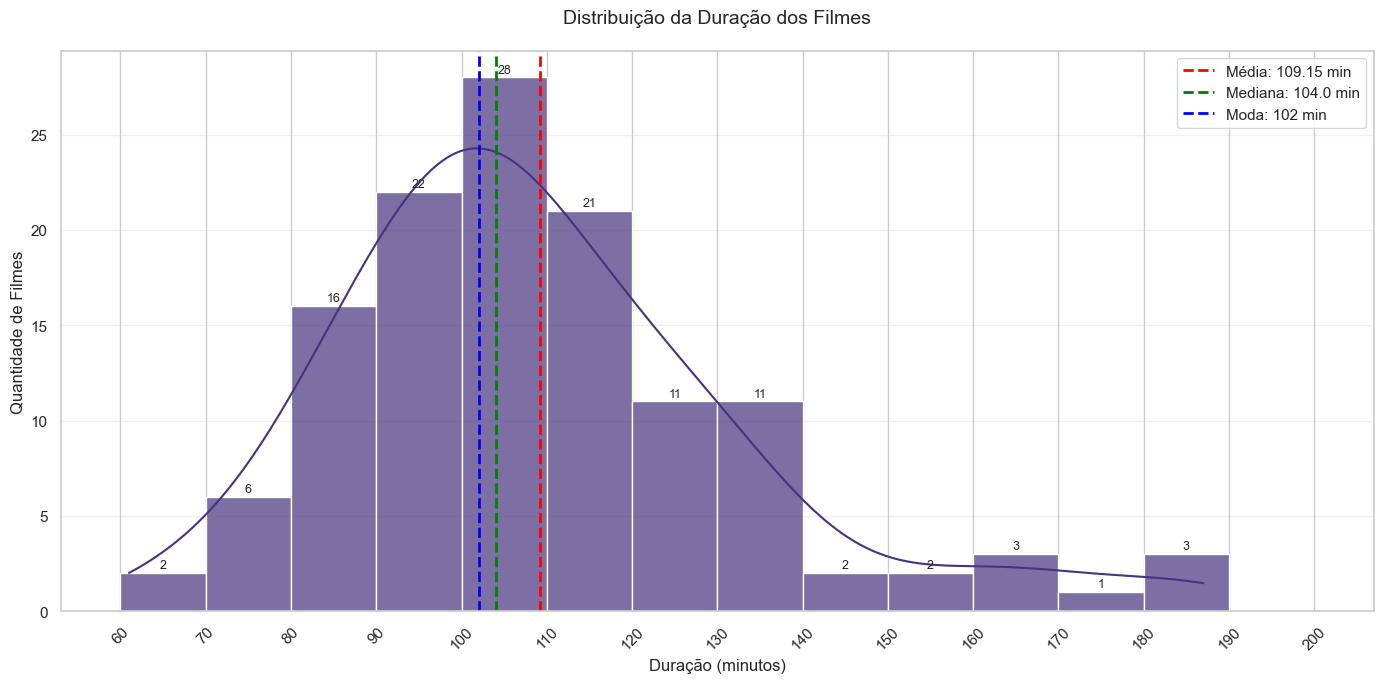


════════════════════════════════════════════════════════════
             DISTRIBUIÇÃO POR FAIXA DE DURAÇÃO              
════════════════════════════════════════════════════════════

Top faixas de duração:
   100-109min: 28 filmes
   90-99min: 22 filmes
   110-119min: 21 filmes
   80-89min: 16 filmes
   120-129min: 11 filmes

Faixa mais comum: 100-109min (28 filmes)


In [3]:
# Usar df_unicos para análise de duração
filme_mais_longo = df_unicos.loc[df_unicos['duracao_minutos'].idxmax()]
filme_mais_curto = df_unicos.loc[df_unicos['duracao_minutos'].idxmin()]

media_duracao = df_unicos['duracao_minutos'].mean()
mediana_duracao = df_unicos['duracao_minutos'].median()
moda_duracao = df_unicos['duracao_minutos'].mode()[0]

print("═" * 60)
print("ANÁLISE DE DURAÇÃO DOS FILMES ÚNICOS".center(60))
print("═" * 60)
print(f"\nFILME MAIS LONGO: {filme_mais_longo['titulo_original']} ({filme_mais_longo['duracao_minutos']} min)")
print(f"FILME MAIS CURTO: {filme_mais_curto['titulo_original']} ({filme_mais_curto['duracao_minutos']} min)")
print(f"\nEstatísticas:")
print(f"   • Total: {len(df_unicos)} filmes únicos")
print(f"   • Média: {media_duracao:.2f} min")
print(f"   • Mediana: {mediana_duracao} min")
print(f"   • Moda: {moda_duracao} min")

# BINS FIXOS de 10 em 10 minutos
min_duracao = 60
max_duracao = df_unicos['duracao_minutos'].max()
bins = list(range(min_duracao, max_duracao + 20, 10))

plt.figure(figsize=(14, 7))
ax = sns.histplot(df_unicos['duracao_minutos'], bins=bins, kde=True, alpha=0.7)

plt.axvline(media_duracao, color='red', linestyle='dashed', linewidth=2, label=f'Média: {media_duracao:.2f} min')
plt.axvline(mediana_duracao, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana_duracao} min')
plt.axvline(moda_duracao, color='blue', linestyle='dashed', linewidth=2, label=f'Moda: {moda_duracao} min')


for rect in ax.patches:
    height = rect.get_height()
    if height > 0:
        ax.text(rect.get_x() + rect.get_width() / 2, height + 0.1,
                f'{int(height)}', ha='center', va='bottom', fontsize=9) # contagem nas barras

plt.title('Distribuição da Duração dos Filmes', fontsize=14, pad=20)
plt.xlabel('Duração (minutos)', fontsize=12)
plt.ylabel('Quantidade de Filmes', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(bins, rotation=45)
plt.tight_layout()
plt.show()

print("\n" + "═" * 60)
print("DISTRIBUIÇÃO POR FAIXA DE DURAÇÃO".center(60))
print("═" * 60)

faixas = []
for i in range(len(bins) - 1):
    faixa_min = bins[i]
    faixa_max = bins[i + 1]
    count = len(df_unicos[(df_unicos['duracao_minutos'] >= faixa_min) & (df_unicos['duracao_minutos'] < faixa_max)])
    if count > 0:
        faixas.append((f"{faixa_min}-{faixa_max-1}min", count))

faixas.sort(key=lambda x: x[1], reverse=True)

print("\nTop faixas de duração:")
for faixa, count in faixas[:5]:
    print(f"   {faixa}: {count} filmes")

print(f"\nFaixa mais comum: {faixas[0][0]} ({faixas[0][1]} filmes)")

### 1.2 Tempo assistido_por pessoa

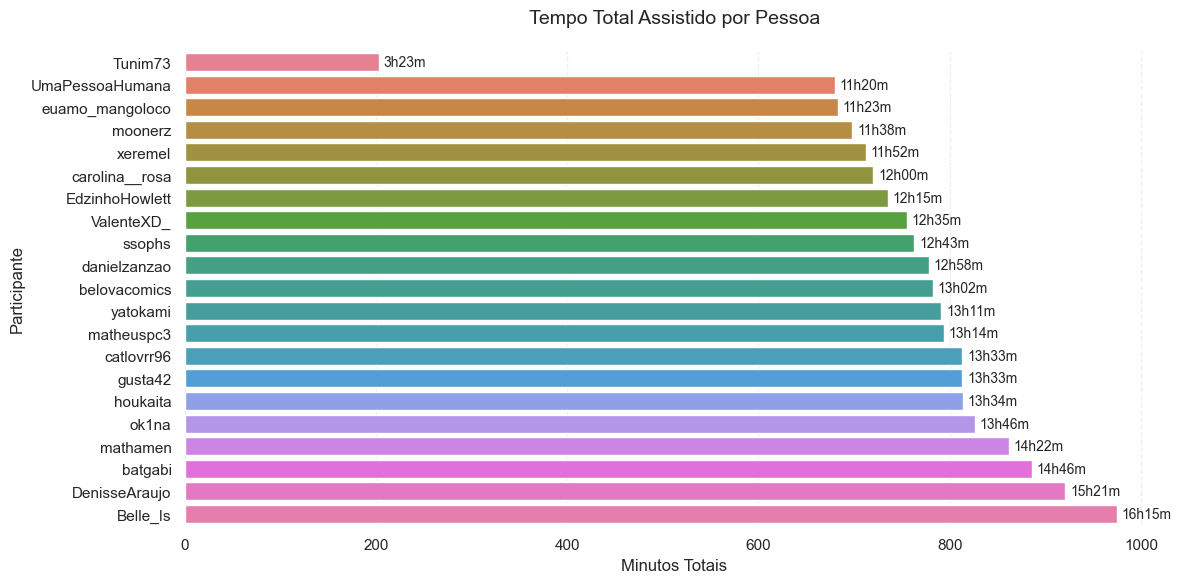

In [4]:
def calcular_tempo_por_pessoa(df, col_pessoas='assistido_por', col_tempo='duracao_minutos'):
    """
    Calcula tempo total por pessoa, lidando com múltiplos participantes por linha
    """
    df_temp = df.copy()
    df_temp[col_pessoas] = df_temp[col_pessoas].str.split(', ')
    df_temp = df_temp.explode(col_pessoas)
    
    df_temp = df_temp[df_temp[col_pessoas].notna()]
    df_temp = df_temp[df_temp[col_pessoas] != '']
    
    tempo_por_pessoa = df_temp.groupby(col_pessoas)[col_tempo].sum().sort_values() # agrupar e somar
    
    return tempo_por_pessoa

tempo_por_pessoa = calcular_tempo_por_pessoa(df_filtrado)

tempo_df = pd.DataFrame({
    'Pessoa': tempo_por_pessoa.index,
    'Minutos': tempo_por_pessoa.values
})

tempo_df['Horas'] = tempo_df['Minutos'] // 60
tempo_df['Minutos_resto'] = tempo_df['Minutos'] % 60
tempo_df['Tempo_Formatado'] = tempo_df.apply(
    lambda x: f"{int(x['Horas'])}h{int(x['Minutos_resto']):02d}m", axis=1
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=tempo_df, x='Minutos', y='Pessoa', hue='Pessoa', dodge=False, legend=False)

for i, (idx, row) in enumerate(tempo_df.iterrows()):
    ax.text(row['Minutos'] + 5, i, row['Tempo_Formatado'], va='center', fontsize=10)

plt.title('Tempo Total Assistido por Pessoa', fontsize=14, pad=20)
plt.xlabel('Minutos Totais', fontsize=12)
plt.ylabel('Participante', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## 2. Gêneros mais vistos

### 2.1 Visão Geral dos gêneros

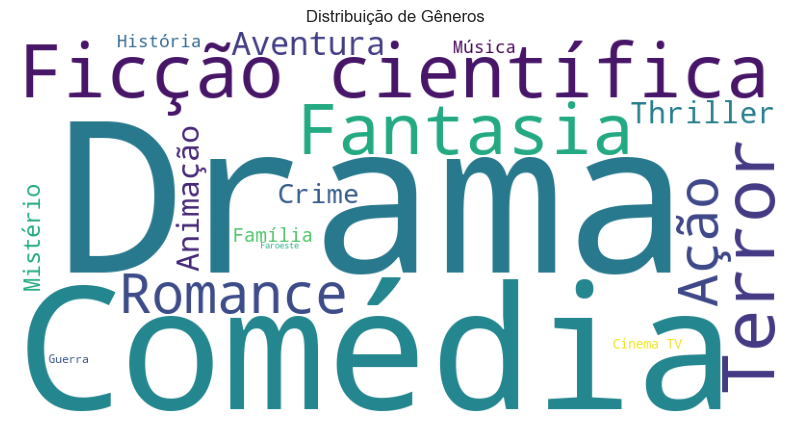

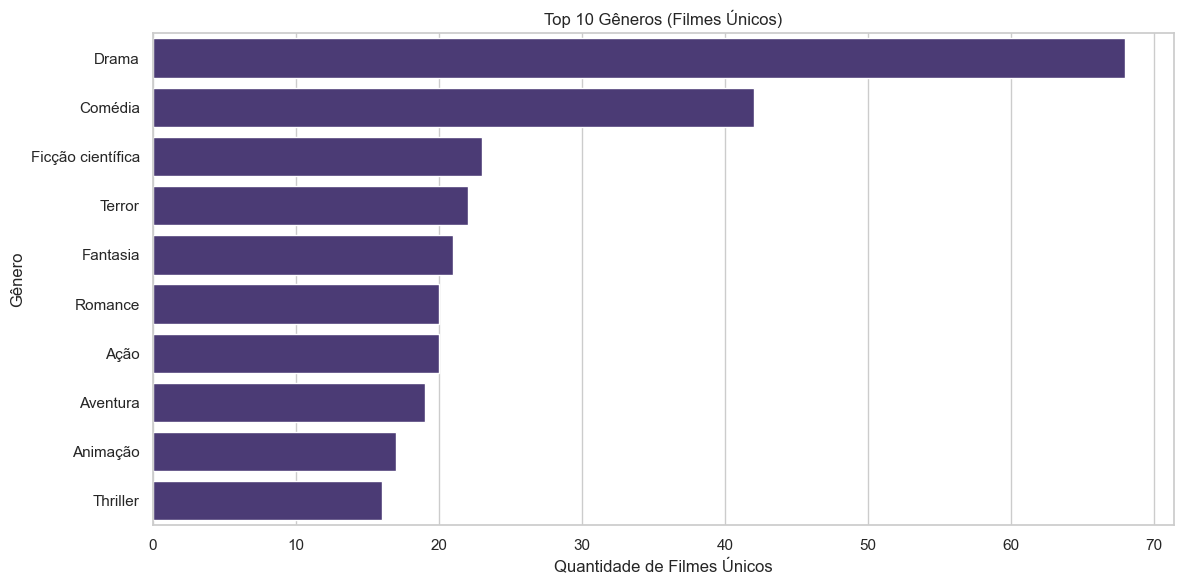

In [5]:
# filmes únicos para não distorcer a análise
df_generos = df_unicos.assign(generos=df_unicos['generos'].str.split(', ')).explode('generos')

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(
    df_generos['generos'].value_counts().to_dict())

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Distribuição de Gêneros')
plt.show()

top_generos = df_generos['generos'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_generos.values, y=top_generos.index)
plt.title('Top 10 Gêneros (Filmes Únicos)')
plt.xlabel('Quantidade de Filmes Únicos')
plt.ylabel('Gênero')
plt.tight_layout()
plt.show()

### 2.2 Gêneros vistos por cada participante

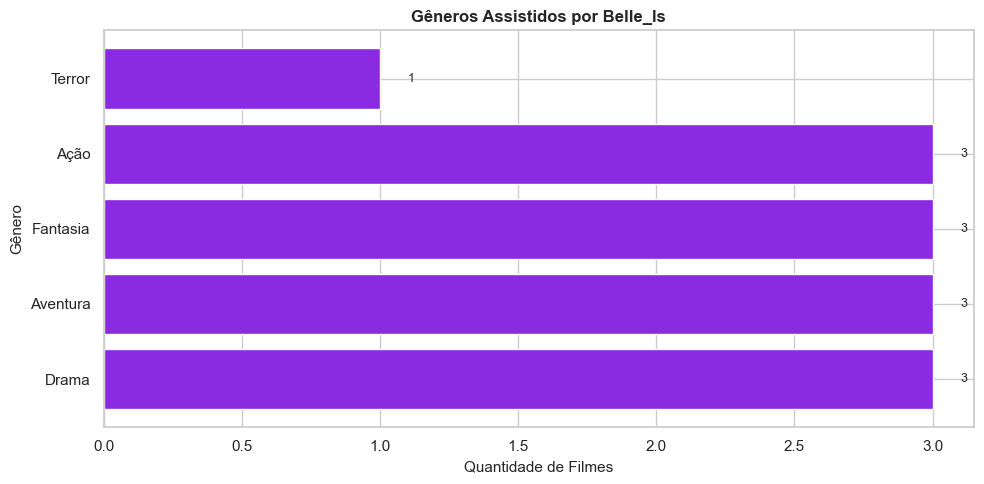

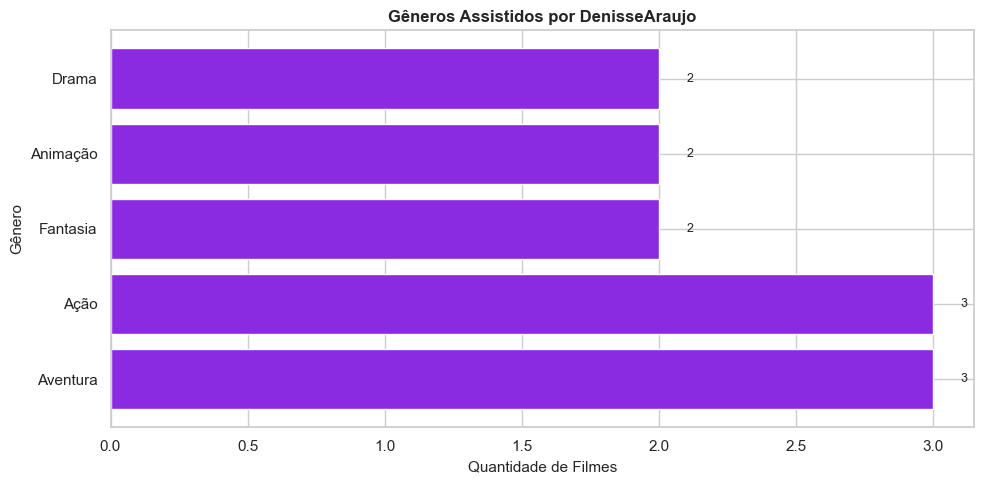

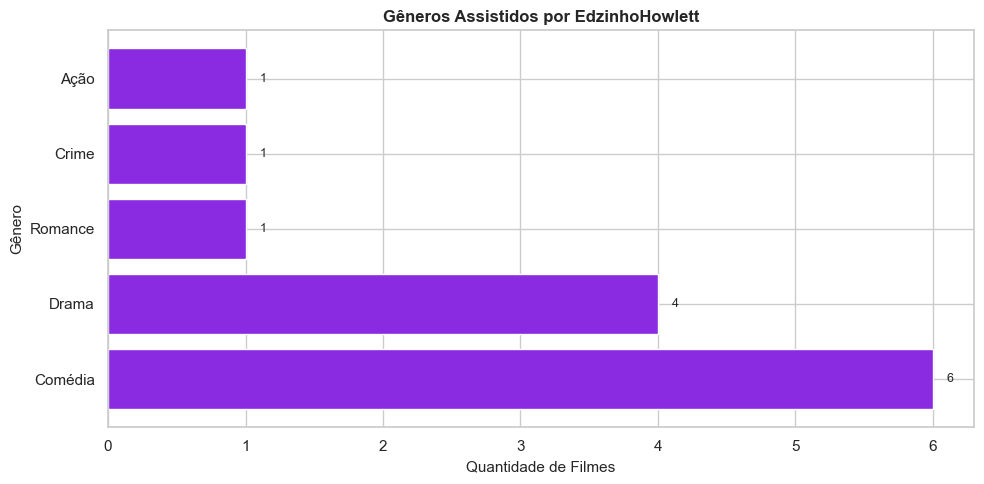

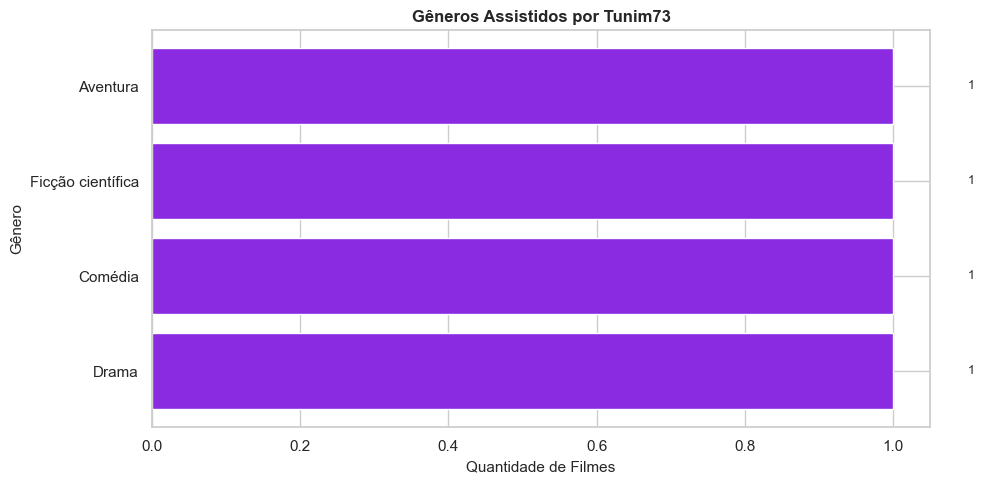

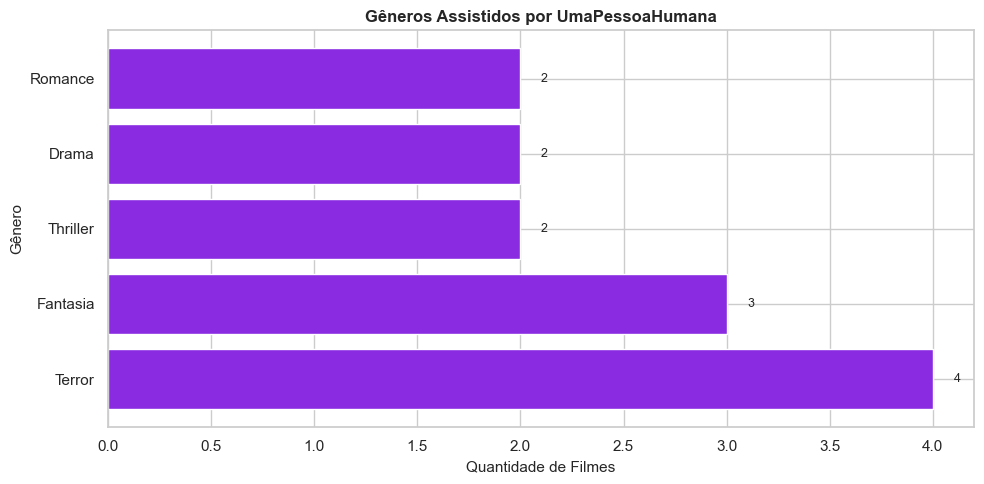

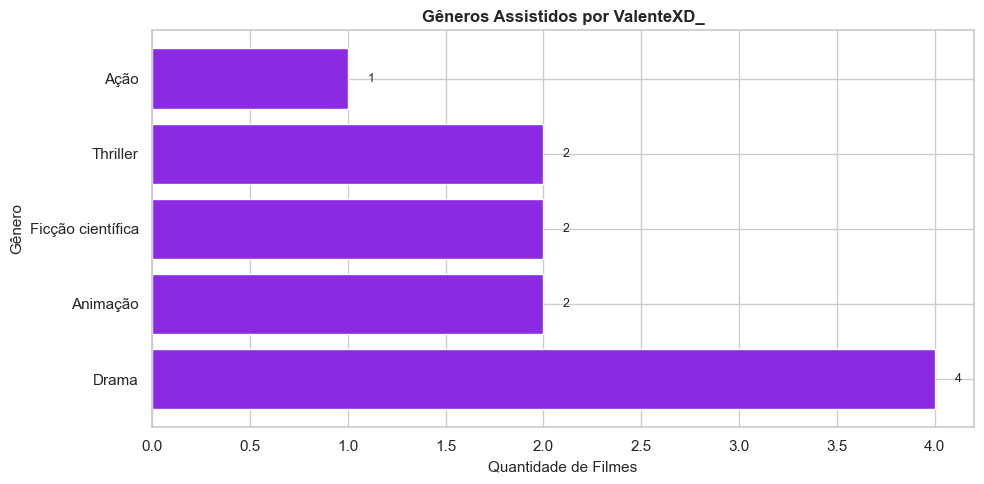

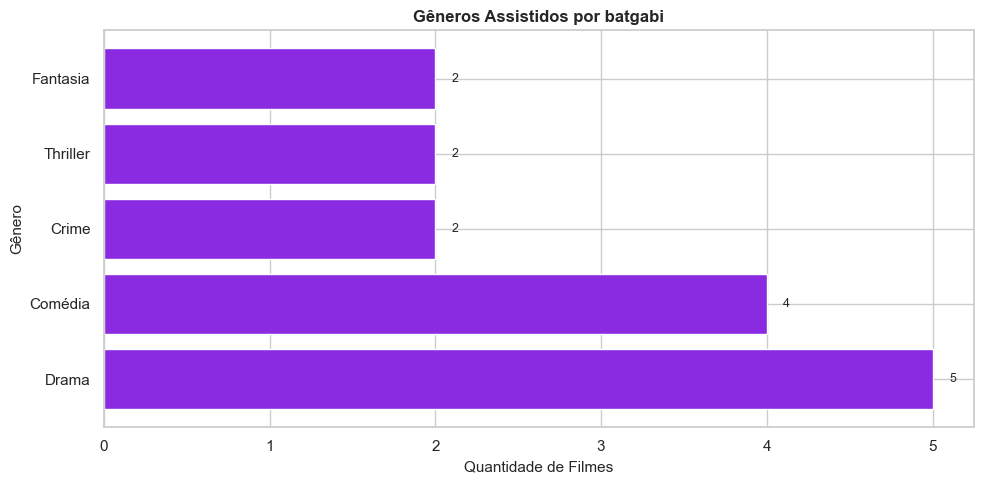

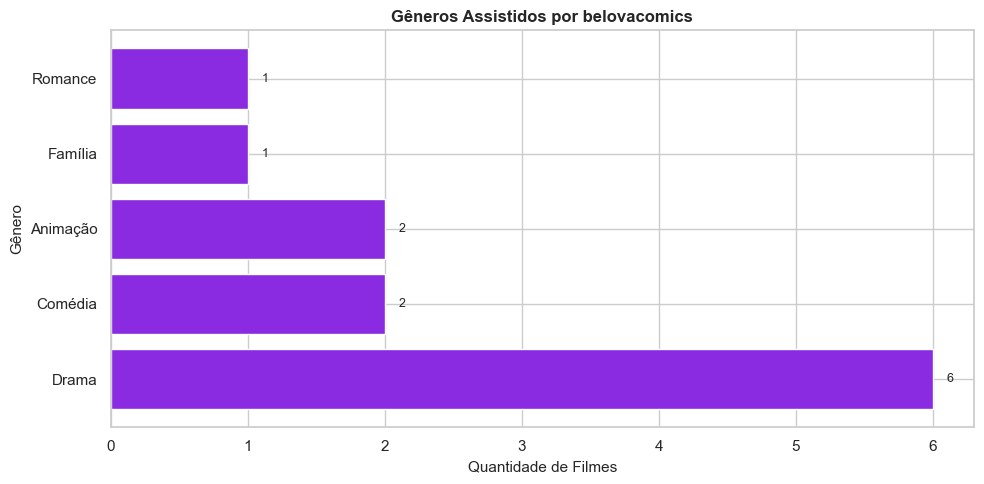

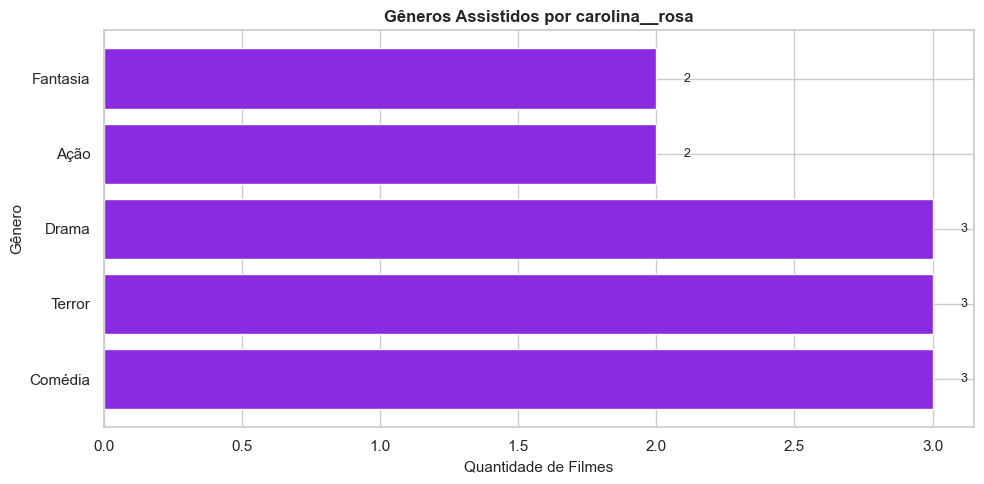

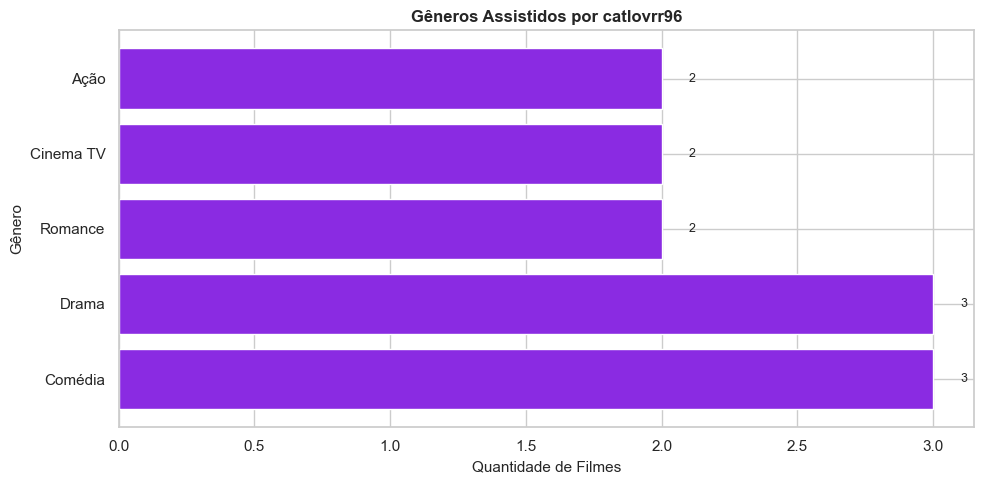

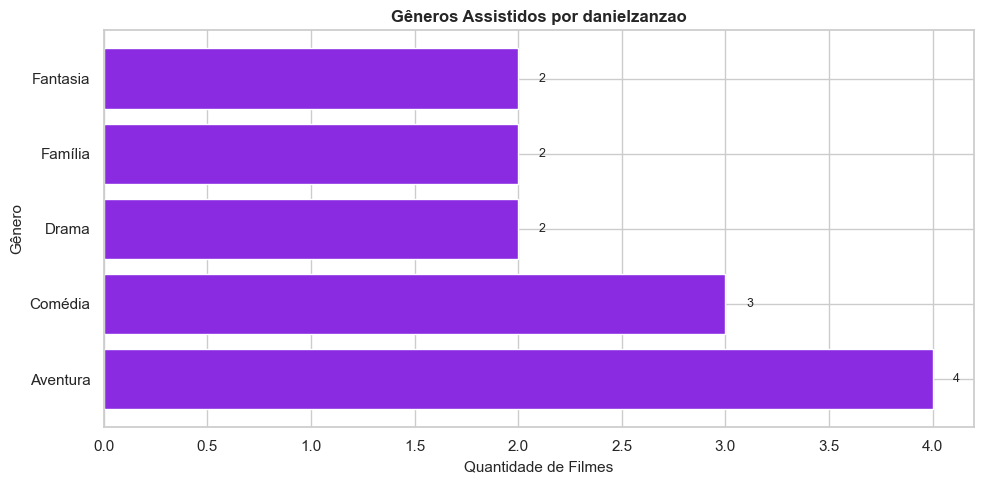

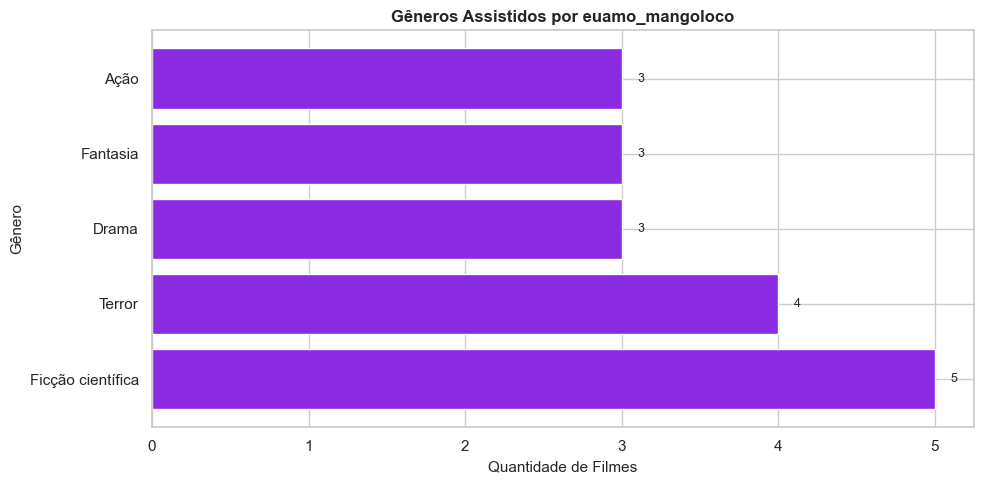

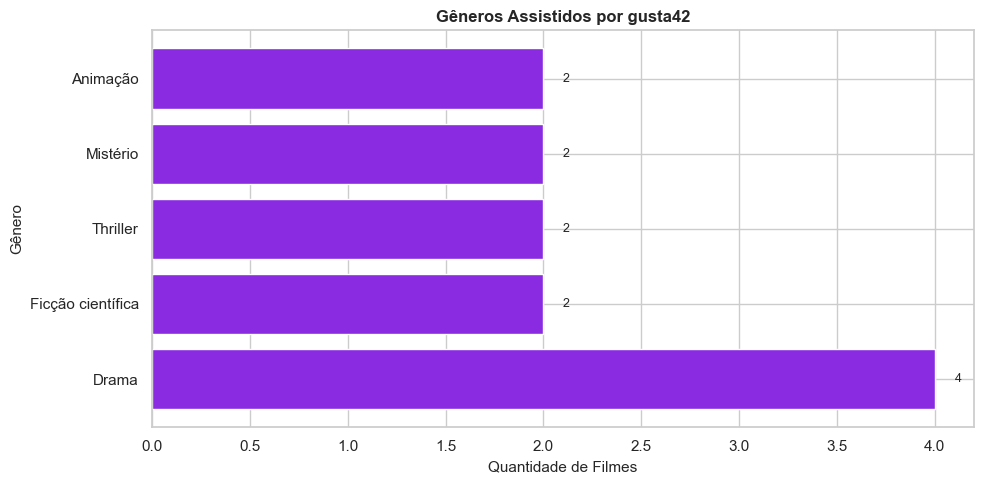

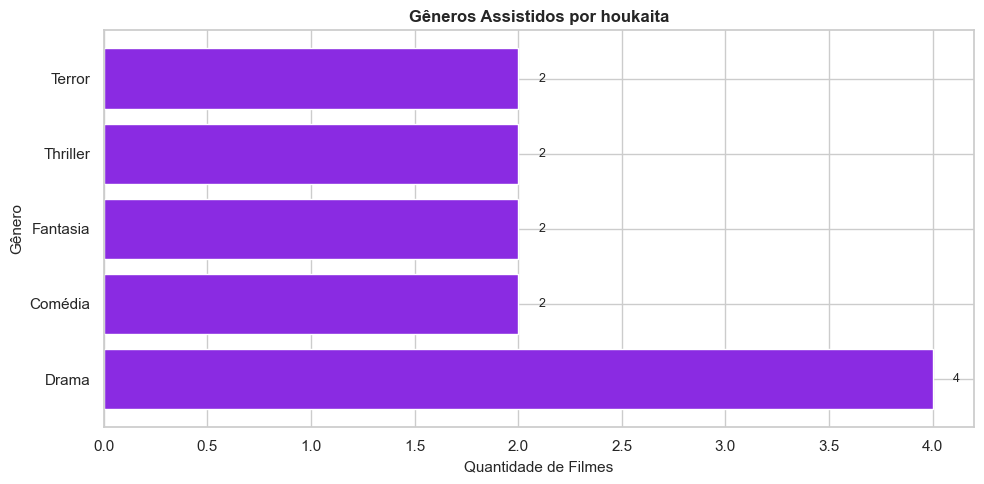

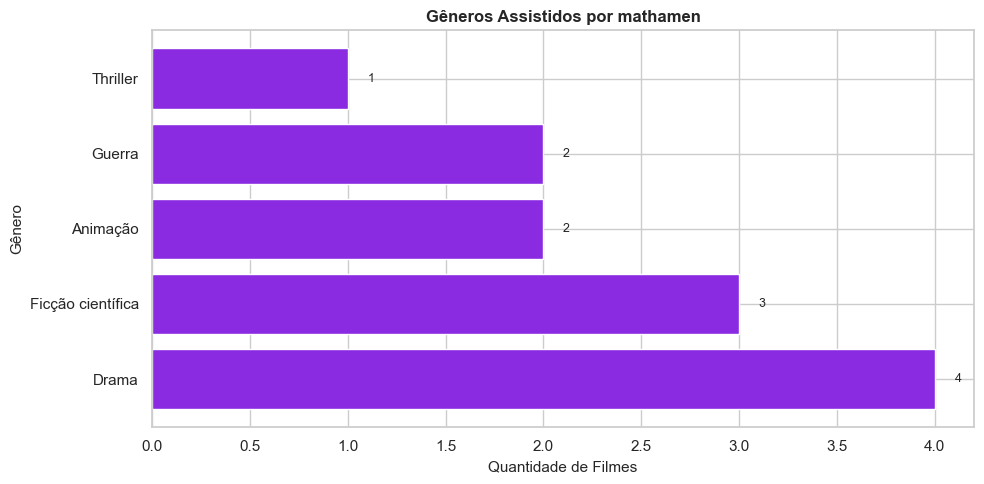

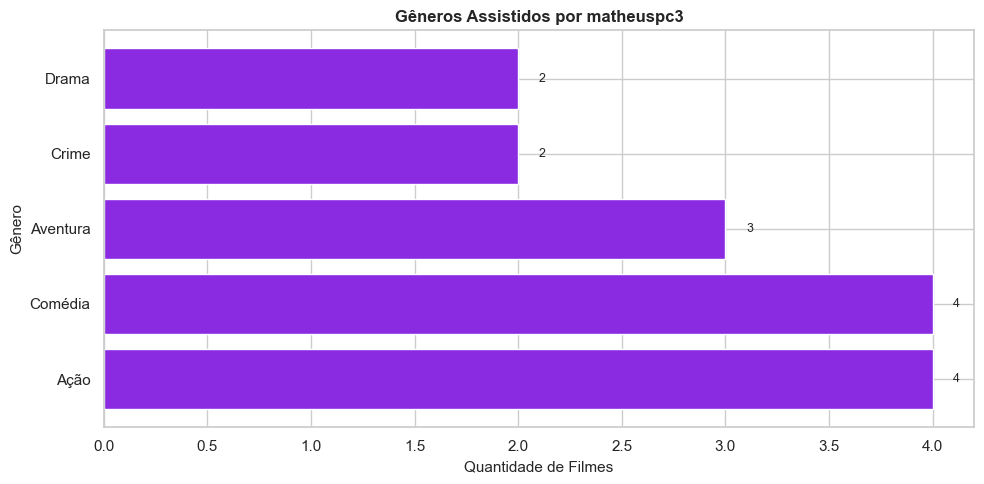

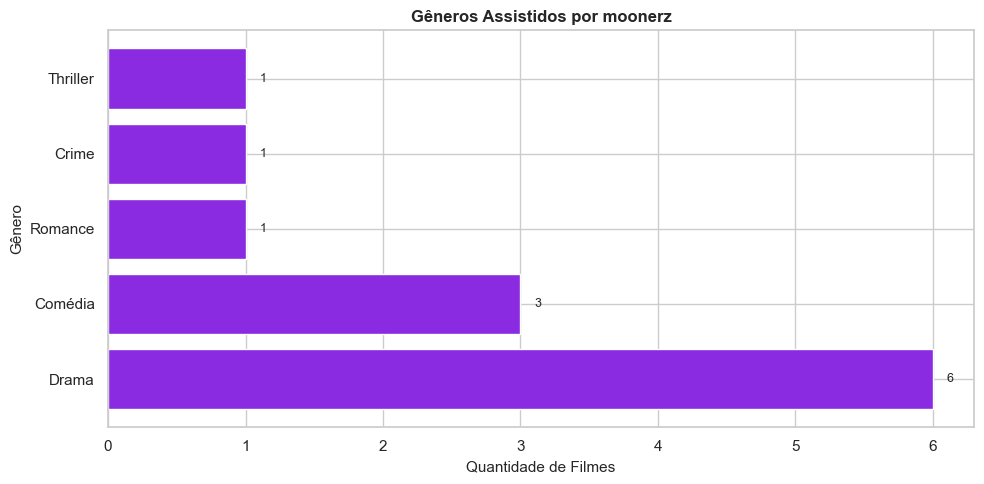

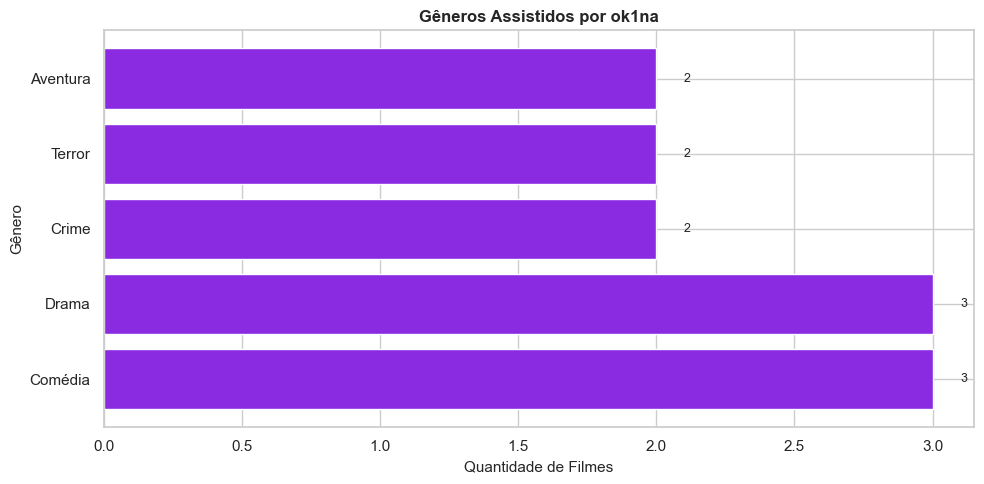

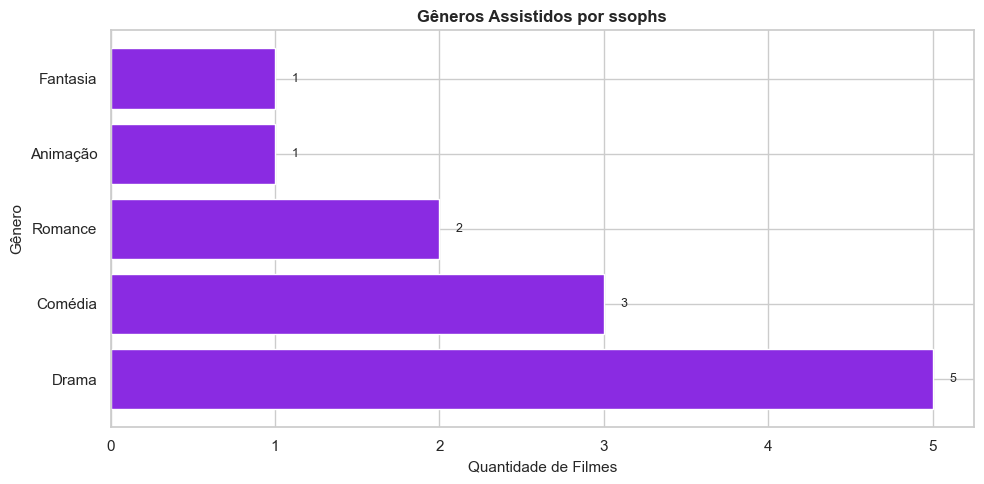

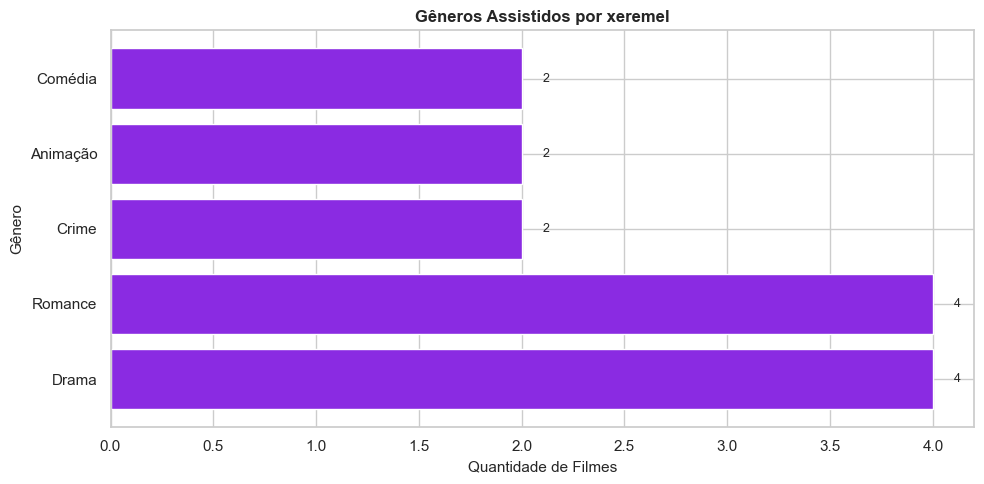

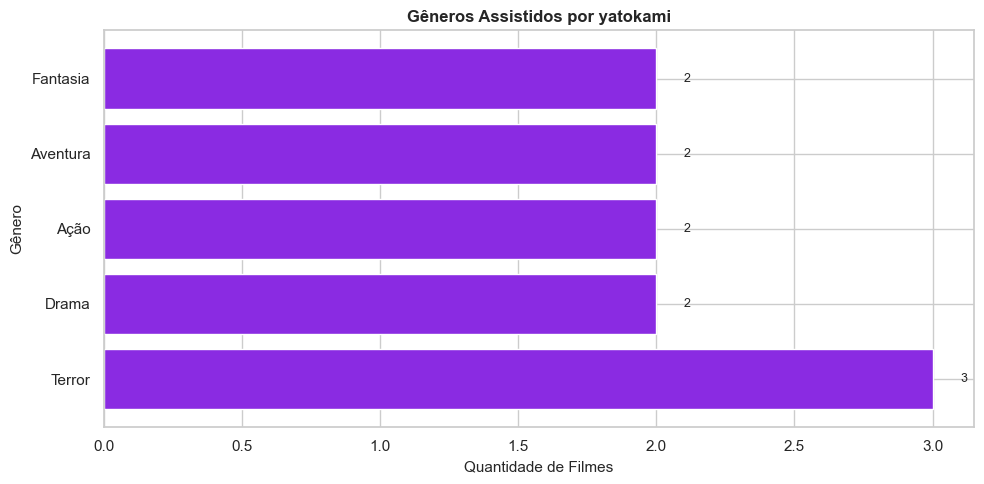

In [6]:
df_temp = df.copy()
df_temp['generos'] = df_temp['generos'].str.split(', ')
df_temp = df_temp.explode('generos')

# Explodir participantes (CRÍTICO!)
df_temp['assistido_por'] = df_temp['assistido_por'].str.split(', ')
df_temp = df_temp.explode('assistido_por')

df_temp = df_temp.dropna(subset=['assistido_por', 'generos'])
df_temp = df_temp[df_temp['assistido_por'] != '']
df_temp = df_temp[df_temp['generos'] != '']

generos_por_participante = df_temp.groupby('assistido_por')['generos'].apply(list)

for participante, generos in generos_por_participante.items():
    contagem = Counter(generos)
    top_5 = contagem.most_common(5)
    
    plt.figure(figsize=(10, 5))
    generos_nomes = [g[0] for g in top_5]
    generos_valores = [g[1] for g in top_5]
    
    # barras horizontais (mais fácil de ler)
    bars = plt.barh(generos_nomes, generos_valores, color='#8A2BE2')
    plt.xlabel('Quantidade de Filmes', fontsize=11)
    plt.ylabel('Gênero', fontsize=11)
    plt.title(f'Gêneros Assistidos por {participante}', fontsize=12, fontweight='bold')

    for bar, valor in zip(bars, generos_valores):
        plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                f'{valor}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

In [7]:
print("═" * 60)
print("ESTATÍSTICAS POR PARTICIPANTE".center(60))
print("═" * 60)

# explodir participantes
df_temp = df_filtrado.copy()
df_temp['assistido_por'] = df_temp['assistido_por'].str.split(', ')
df_temp = df_temp.explode('assistido_por')
df_temp = df_temp[df_temp['assistido_por'].notna()]
df_temp = df_temp[df_temp['assistido_por'] != '']

for participante in df_temp['assistido_por'].unique():
    filmes_participante = df_temp[df_temp['assistido_por'] == participante]
    filmes_unicos = filmes_participante.drop_duplicates(subset=['titulo_original'])
    
    print(f"\n{participante}:")
    print(f"   • Total de visualizações: {len(filmes_participante)}")
    print(f"   • Filmes únicos assistidos: {len(filmes_unicos)}")
    print(f"   • Tempo total: {filmes_participante['duracao_minutos'].sum()} minutos")
    
    # se tiver a coluna Década
    if 'Década' in filmes_unicos.columns and len(filmes_unicos) > 0:
        decada_counts = filmes_unicos['Década'].value_counts()
        if len(decada_counts) > 0:
            print(f"   • Década preferida: {decada_counts.idxmax()}s")

════════════════════════════════════════════════════════════
               ESTATÍSTICAS POR PARTICIPANTE                
════════════════════════════════════════════════════════════

gusta42:
   • Total de visualizações: 7
   • Filmes únicos assistidos: 7
   • Tempo total: 813 minutos
   • Década preferida: 2000s

mathamen:
   • Total de visualizações: 7
   • Filmes únicos assistidos: 7
   • Tempo total: 862 minutos
   • Década preferida: 1980s

DenisseAraujo:
   • Total de visualizações: 7
   • Filmes únicos assistidos: 7
   • Tempo total: 921 minutos
   • Década preferida: 2020s

ssophs:
   • Total de visualizações: 7
   • Filmes únicos assistidos: 7
   • Tempo total: 763 minutos
   • Década preferida: 2010s

ValenteXD_:
   • Total de visualizações: 7
   • Filmes únicos assistidos: 7
   • Tempo total: 755 minutos
   • Década preferida: 2020s

danielzanzao:
   • Total de visualizações: 7
   • Filmes únicos assistidos: 7
   • Tempo total: 778 minutos
   • Década preferida: 2020s

Edzi

## 3. Distribuição de Décadas

In [8]:
filme_mais_antigo = df.loc[df['ano_lancamento'].idxmin()]
ano_mais_novo = df['ano_lancamento'].max()
filmes_mais_novos = df[df['ano_lancamento'] == ano_mais_novo]

media_ano = df['ano_lancamento'].mean()
mediana_ano = df['ano_lancamento'].median()
moda_ano = df['ano_lancamento'].mode()[0]

print(f"Filme mais antigo: {filme_mais_antigo['titulo_original']} ({filme_mais_antigo['ano_lancamento']})")
print(f"Filmes mais novos ({ano_mais_novo}):")
for idx, filme in filmes_mais_novos.iterrows():
    print(f"  - {filme['titulo_original']} ({filme['pais']})")
print(f"Média dos anos: {media_ano:.2f}")
print(f"Mediana dos anos: {mediana_ano}")
print(f"Moda dos anos: {moda_ano}")

Filme mais antigo: Körkarlen (1921)
Filmes mais novos (2026):
  - Project Hail Mary (United States of America)
  - The Invite (United States of America)
  - Toy Story 5 (United States of America)
  - Enola Holmes 3 (United States of America)
  - Evil Dead Burn (United States of America)
  - Remarkably Bright Creatures (United States of America)
  - Obsession (United States of America)
  - The Odyssey (United Kingdom)
  - 남편들 (South Korea)
Média dos anos: 2002.62
Mediana dos anos: 2009.0
Moda dos anos: 2025


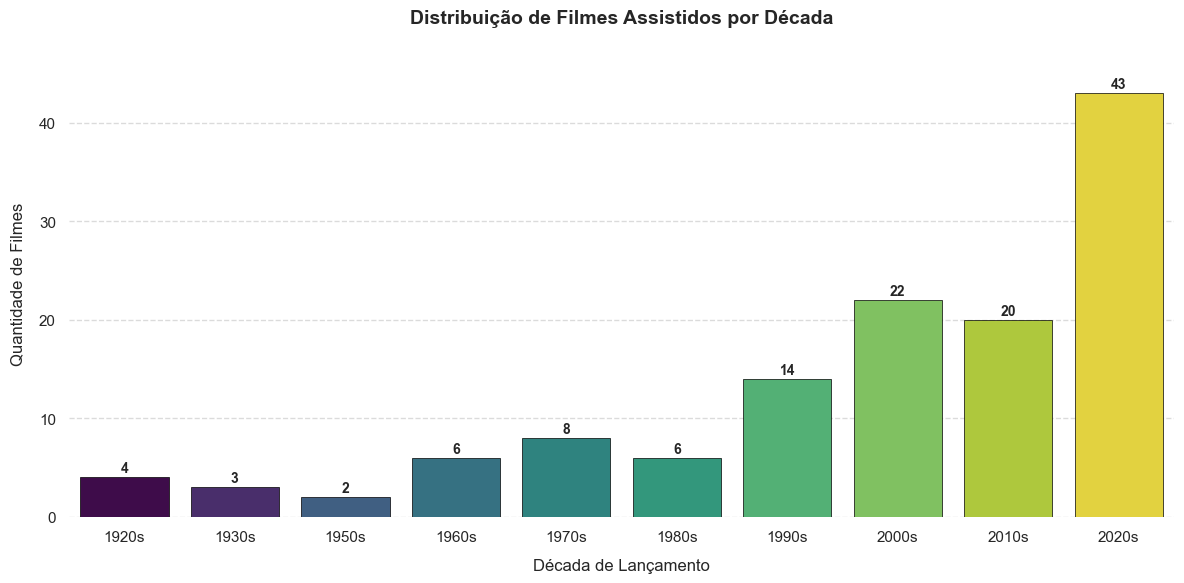

In [9]:
df['Decada'] = (df['ano_lancamento'] // 10) * 10

# Contar quantos filmes temos em cada década
filmes_por_decada = df['Decada'].value_counts().sort_index()

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=filmes_por_decada.index.astype(str),  # convertendo para string pra evitar confusão numérica
    y=filmes_por_decada.values,
    hue=filmes_por_decada.index,  # resolve o warning da palette
    palette="viridis",
    edgecolor='black',
    linewidth=0.5,
    dodge=False,
    legend=False
)

#valores no topo de cada barra
for i, valor in enumerate(filmes_por_decada.values):
    ax.text(
        i, 
        valor + 0.2,
        f'{valor}', 
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

decadas = [f"{int(decada)}s" for decada in filmes_por_decada.index]
ax.set_xticks(range(len(decadas)))
ax.set_xticklabels(decadas)

plt.title('Distribuição de Filmes Assistidos por Década', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Década de Lançamento', labelpad=10)
plt.ylabel('Quantidade de Filmes', labelpad=10)
plt.ylim(0, filmes_por_decada.max() * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

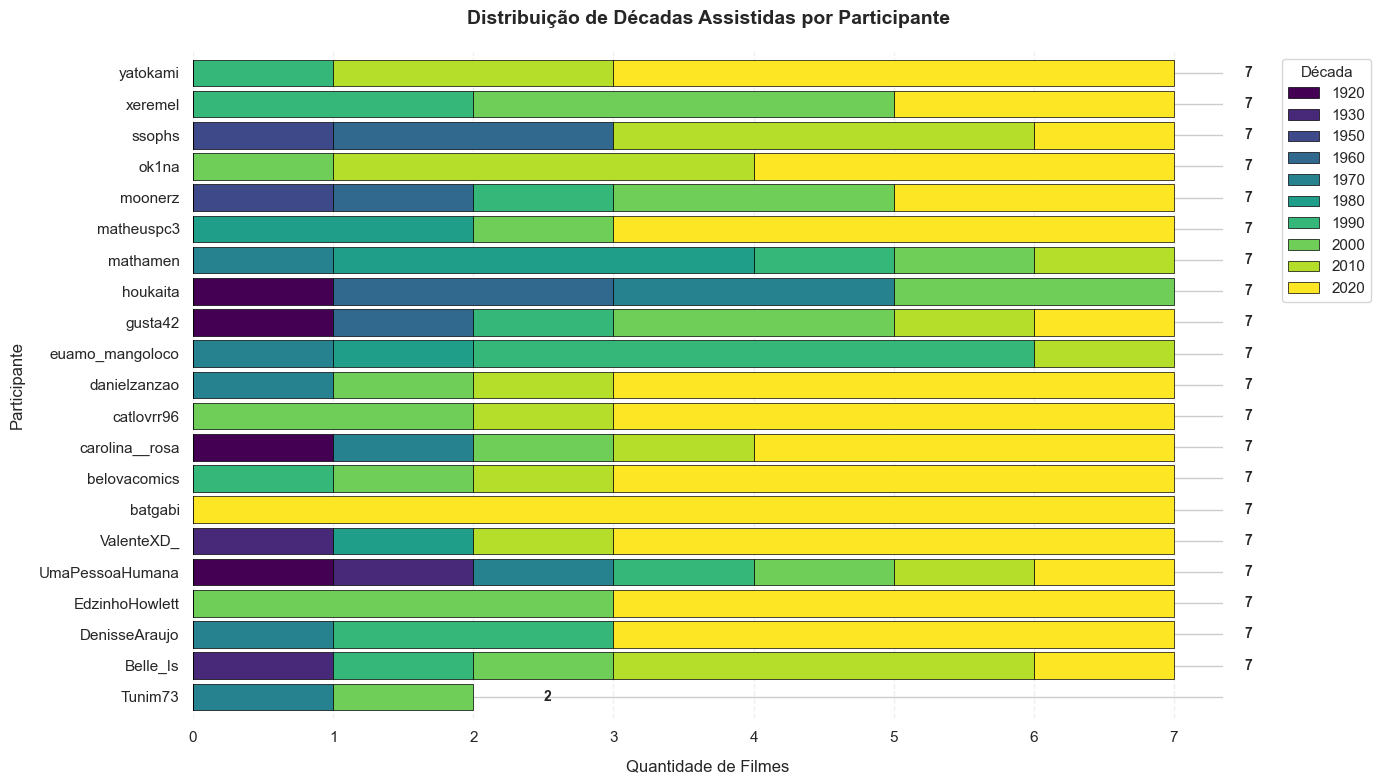


Tabela de Referência (Filmes por Década e Participante):


,1920s,1930s,1950s,1960s,1970s,1980s,1990s,2000s,2010s,2020s,Total
assistido_por,,,,,,,,,,,
Belle_Is,0,1,0,0,0,0,1,1,3,1,7
EdzinhoHowlett,0,0,0,0,0,0,0,3,0,4,7
DenisseAraujo,0,0,0,0,1,0,2,0,0,4,7
UmaPessoaHumana,1,1,0,0,1,0,1,1,1,1,7
ValenteXD_,0,1,0,0,0,1,0,0,1,4,7
houkaita,1,0,0,2,2,0,0,2,0,0,7
batgabi,0,0,0,0,0,0,0,0,0,7,7
belovacomics,0,0,0,0,0,0,1,1,1,4,7
carolina__rosa,1,0,0,0,1,0,0,1,1,3,7



Visualização alternativa - Mapa de Calor:


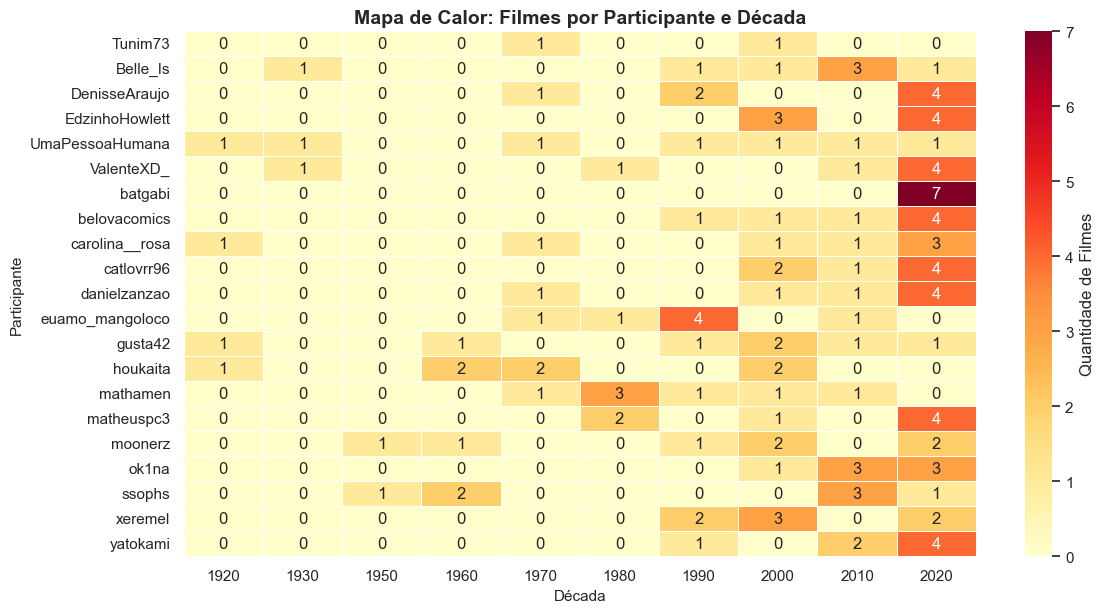

In [10]:
# FILTRAR QUEM NÃO VAI ENTRAR NA ANALISE
participantes_excluidos = []
df_filtrado = df[~df['assistido_por'].isin(participantes_excluidos)].copy()

# PRIMEIRO: Explodir a coluna 'assistido_por' para separar participantes individuais
df_filtrado['assistido_por'] = df_filtrado['assistido_por'].str.split(', ')
df_filtrado = df_filtrado.explode('assistido_por')

df_filtrado = df_filtrado[df_filtrado['assistido_por'].notna()]
df_filtrado = df_filtrado[df_filtrado['assistido_por'] != '']


df_filtrado.loc[:, 'Década'] = (df_filtrado['ano_lancamento'] // 10) * 10

df_filtrado = df_filtrado[df_filtrado['Década'].notna()]

decadas_por_participante = df_filtrado.groupby(['assistido_por', 'Década']).size().unstack(fill_value=0)
decadas_por_participante['Total'] = decadas_por_participante.sum(axis=1)
decadas_por_participante = decadas_por_participante.sort_values('Total', ascending=True)
decadas_por_participante = decadas_por_participante.drop('Total', axis=1)

plt.figure(figsize=(14, max(8, len(decadas_por_participante) * 0.3)))

ax = decadas_por_participante.plot(
    kind='barh',
    stacked=True,
    colormap='viridis',
    edgecolor='black',
    linewidth=0.5,
    width=0.85,
    figsize=(14, max(8, len(decadas_por_participante) * 0.3))
)

plt.title('Distribuição de Décadas Assistidas por Participante', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Filmes', labelpad=10, fontsize=12)
plt.ylabel('Participante', labelpad=10, fontsize=12)
plt.legend(title='Década', bbox_to_anchor=(1.05, 1), loc='upper left', title_fontsize=11)


for i, (idx, row) in enumerate(decadas_por_participante.iterrows()):
    total = row.sum()
    if total > 0:
        ax.text(total + 0.5, i, f'{int(total)}', va='center', fontweight='bold', fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


print("\nTabela de Referência (Filmes por Década e Participante):")
print("="*80)

tabela_exibicao = decadas_por_participante.copy()
tabela_exibicao.columns = [f"{int(col)}s" for col in tabela_exibicao.columns]  # Formata décadas
tabela_exibicao['Total'] = tabela_exibicao.sum(axis=1)
tabela_exibicao = tabela_exibicao.sort_values('Total', ascending=False)

display(tabela_exibicao.style.background_gradient(cmap='viridis', axis=1))

# Extra: Gráfico de calor para visualizar concentração
print("\nVisualização alternativa - Mapa de Calor:")
plt.figure(figsize=(12, max(6, len(decadas_por_participante) * 0.3)))

# Criar heatmap
sns.heatmap(
    decadas_por_participante,
    annot=True,
    fmt='g',
    cmap='YlOrRd',
    cbar_kws={'label': 'Quantidade de Filmes'},
    linewidths=0.5,
    linecolor='white'
)

plt.title('Mapa de Calor: Filmes por Participante e Década', fontsize=14, fontweight='bold')
plt.xlabel('Década', fontsize=11)
plt.ylabel('Participante', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Países assistidos

════════════════════════════════════════════════════════════
                     ANÁLISE DE PAÍSES                      
════════════════════════════════════════════════════════════


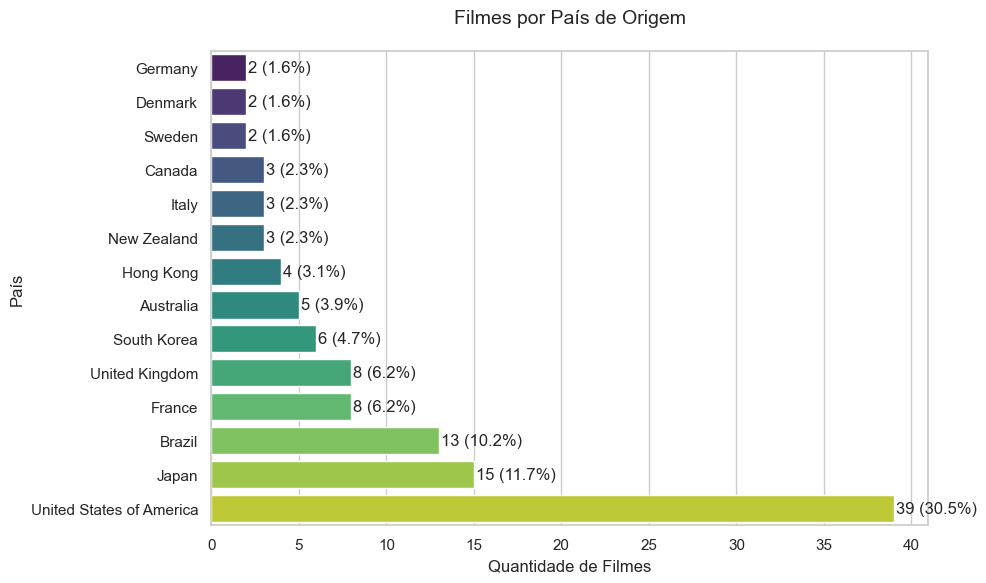


Total de países representados: 29
Países com apenas 1 filme: 15
   Soviet Union, Taiwan, Iran, Turkey, Hungary, Morocco, India, China, Argentina, Latvia, Belgium, Bulgaria, Pakistan, Austria, Thailand


In [11]:
# Análise de países (filmes únicos)
df_paises = df_unicos.assign(pais=df_unicos['pais'].str.split(', ')).explode('pais')
contagem_paises = df_paises['pais'].value_counts()

print("═" * 60)
print("ANÁLISE DE PAÍSES".center(60))
print("═" * 60)

# Top países
paises_top = contagem_paises[contagem_paises >= 2]
paises_unicos = contagem_paises[contagem_paises == 1]

df_paises_plot = paises_top.reset_index()
df_paises_plot.columns = ['pais', 'Quantidade']
df_paises_plot = df_paises_plot.sort_values('Quantidade', ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_paises_plot, x='Quantidade', y='pais', hue='pais', 
            palette="viridis", dodge=False, legend=False)

# Adicionar valores e porcentagens
total_filmes = contagem_paises.sum()
for i, (pais, qtd) in enumerate(zip(df_paises_plot['pais'], df_paises_plot['Quantidade'])):
    porcentagem = (qtd / total_filmes) * 100
    plt.text(qtd + 0.1, i, f"{qtd} ({porcentagem:.1f}%)", va='center')

plt.title('Filmes por País de Origem', fontsize=14, pad=20)
plt.xlabel('Quantidade de Filmes', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nTotal de países representados: {len(contagem_paises)}")
print(f"Países com apenas 1 filme: {len(paises_unicos)}")
if len(paises_unicos) > 0:
    print("   " + ", ".join(paises_unicos.index.tolist()))

            GRÁFICOS DE PAÍSES POR PARTICIPANTE             



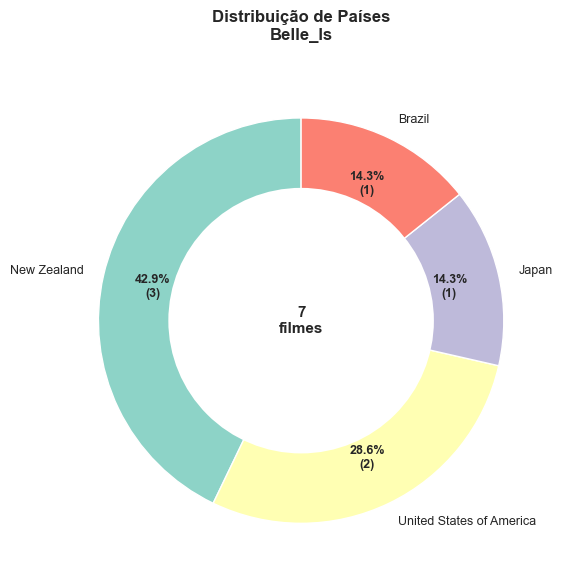


Análise de países para Belle_Is:
   Total de filmes: 7
   Países únicos: 4

  Detalhamento completo:
   New Zealand              :  3 filmes ( 42.9%) ████████
   United States of America :  2 filmes ( 28.6%) █████
   Japan                    :  1 filmes ( 14.3%) ██
   Brazil                   :  1 filmes ( 14.3%) ██




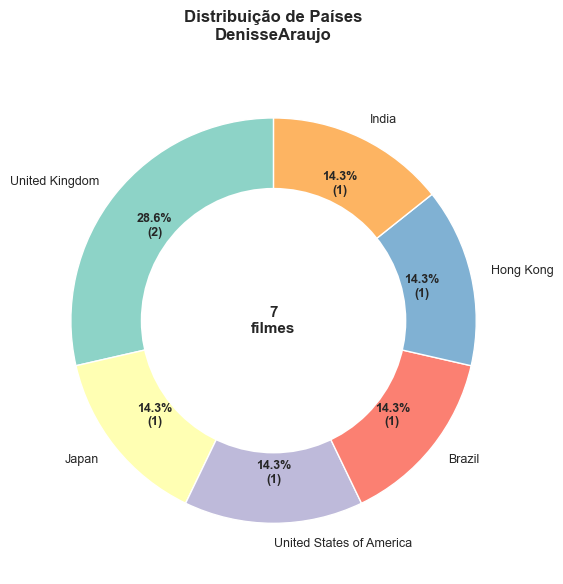


Análise de países para DenisseAraujo:
   Total de filmes: 7
   Países únicos: 6

  Detalhamento completo:
   United Kingdom           :  2 filmes ( 28.6%) █████
   Japan                    :  1 filmes ( 14.3%) ██
   United States of America :  1 filmes ( 14.3%) ██
   Brazil                   :  1 filmes ( 14.3%) ██
   Hong Kong                :  1 filmes ( 14.3%) ██
   India                    :  1 filmes ( 14.3%) ██




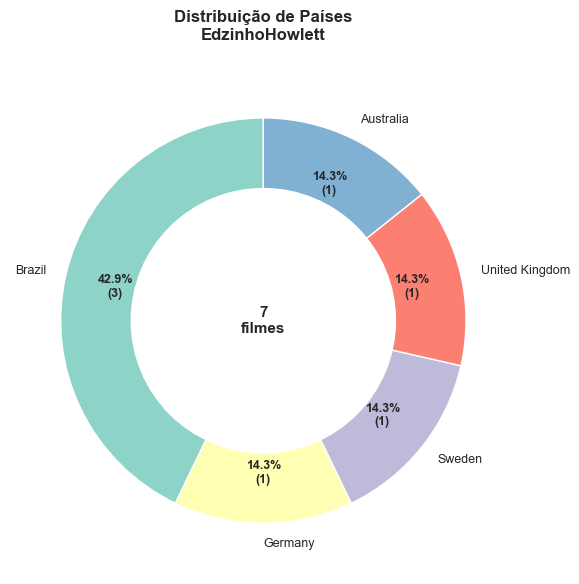


Análise de países para EdzinhoHowlett:
   Total de filmes: 7
   Países únicos: 5

  Detalhamento completo:
   Brazil                   :  3 filmes ( 42.9%) ████████
   Germany                  :  1 filmes ( 14.3%) ██
   Sweden                   :  1 filmes ( 14.3%) ██
   United Kingdom           :  1 filmes ( 14.3%) ██
   Australia                :  1 filmes ( 14.3%) ██




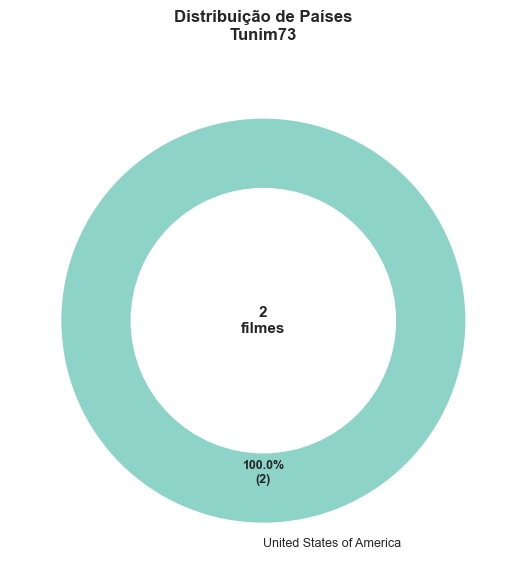


Análise de países para Tunim73:
   Total de filmes: 2
   Países únicos: 1

  Detalhamento completo:
   United States of America :  2 filmes (100.0%) ████████████████████




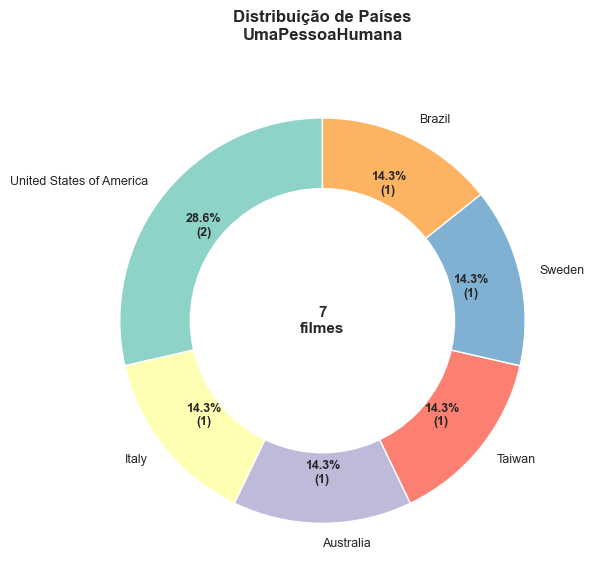


Análise de países para UmaPessoaHumana:
   Total de filmes: 7
   Países únicos: 6

  Detalhamento completo:
   United States of America :  2 filmes ( 28.6%) █████
   Italy                    :  1 filmes ( 14.3%) ██
   Australia                :  1 filmes ( 14.3%) ██
   Taiwan                   :  1 filmes ( 14.3%) ██
   Sweden                   :  1 filmes ( 14.3%) ██
   Brazil                   :  1 filmes ( 14.3%) ██




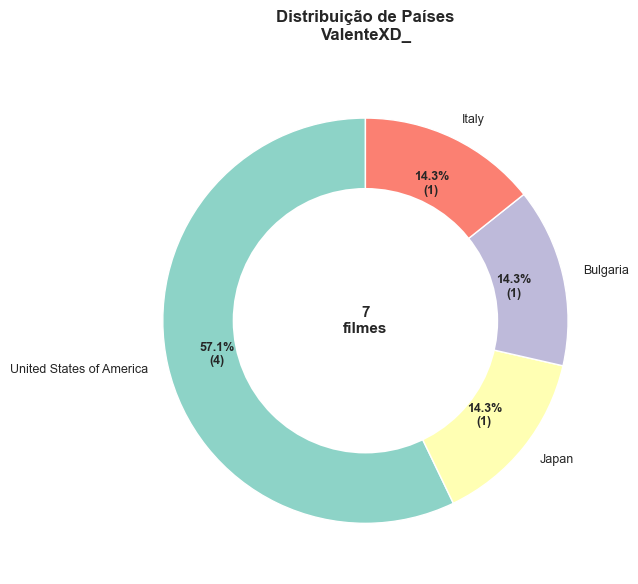


Análise de países para ValenteXD_:
   Total de filmes: 7
   Países únicos: 4

  Detalhamento completo:
   United States of America :  4 filmes ( 57.1%) ███████████
   Japan                    :  1 filmes ( 14.3%) ██
   Bulgaria                 :  1 filmes ( 14.3%) ██
   Italy                    :  1 filmes ( 14.3%) ██




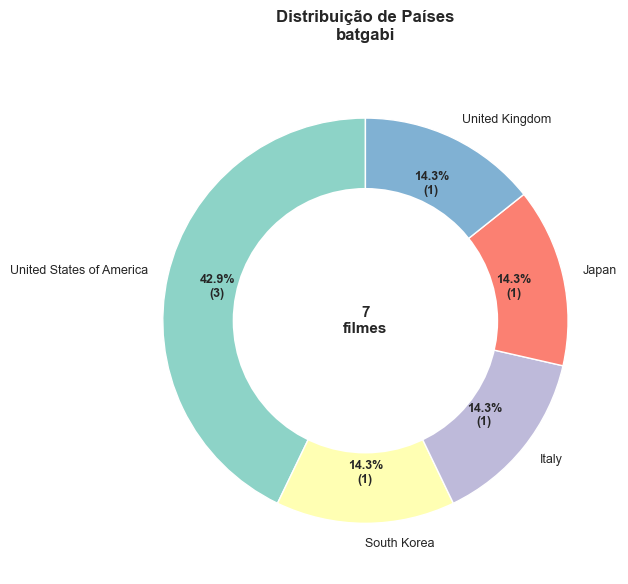


Análise de países para batgabi:
   Total de filmes: 7
   Países únicos: 5

  Detalhamento completo:
   United States of America :  3 filmes ( 42.9%) ████████
   South Korea              :  1 filmes ( 14.3%) ██
   Italy                    :  1 filmes ( 14.3%) ██
   Japan                    :  1 filmes ( 14.3%) ██
   United Kingdom           :  1 filmes ( 14.3%) ██




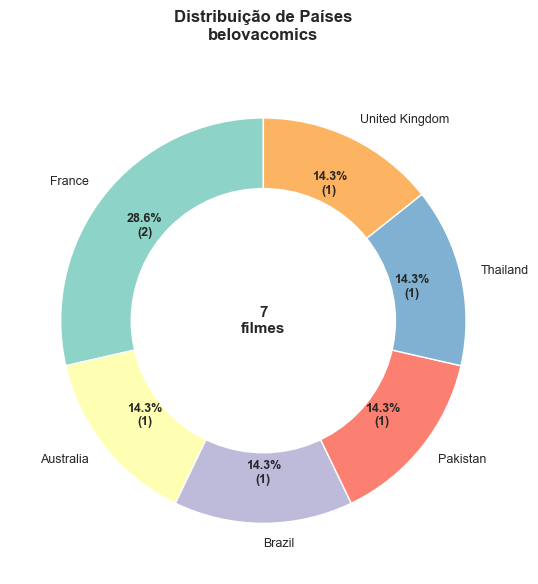


Análise de países para belovacomics:
   Total de filmes: 7
   Países únicos: 6

  Detalhamento completo:
   France                   :  2 filmes ( 28.6%) █████
   Australia                :  1 filmes ( 14.3%) ██
   Brazil                   :  1 filmes ( 14.3%) ██
   Pakistan                 :  1 filmes ( 14.3%) ██
   Thailand                 :  1 filmes ( 14.3%) ██
   United Kingdom           :  1 filmes ( 14.3%) ██




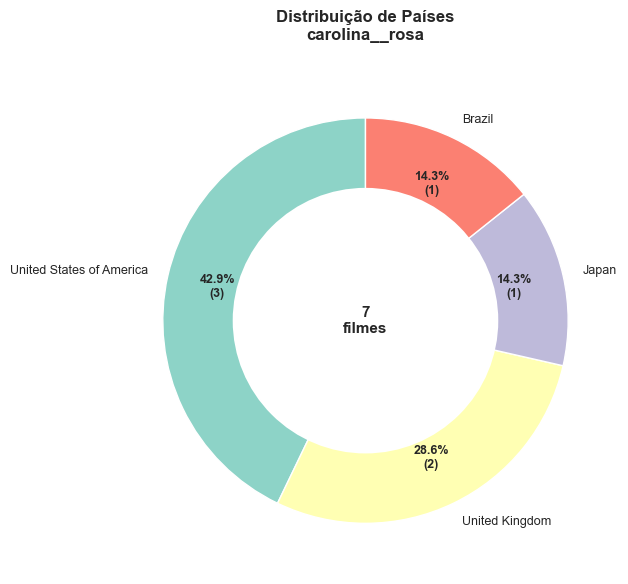


Análise de países para carolina__rosa:
   Total de filmes: 7
   Países únicos: 4

  Detalhamento completo:
   United States of America :  3 filmes ( 42.9%) ████████
   United Kingdom           :  2 filmes ( 28.6%) █████
   Japan                    :  1 filmes ( 14.3%) ██
   Brazil                   :  1 filmes ( 14.3%) ██




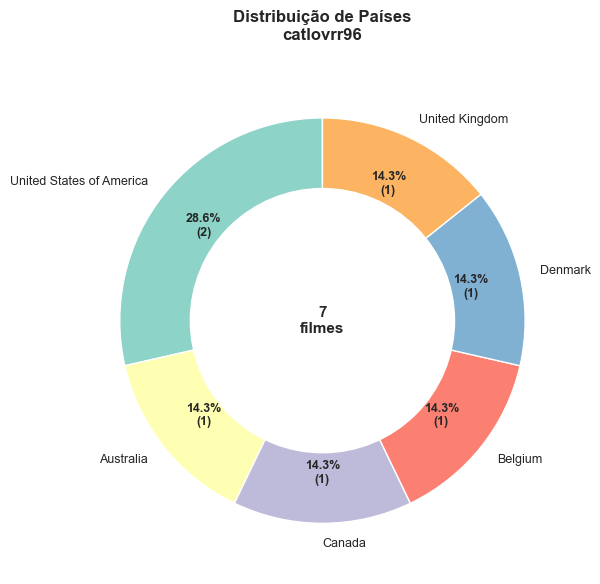


Análise de países para catlovrr96:
   Total de filmes: 7
   Países únicos: 6

  Detalhamento completo:
   United States of America :  2 filmes ( 28.6%) █████
   Australia                :  1 filmes ( 14.3%) ██
   Canada                   :  1 filmes ( 14.3%) ██
   Belgium                  :  1 filmes ( 14.3%) ██
   Denmark                  :  1 filmes ( 14.3%) ██
   United Kingdom           :  1 filmes ( 14.3%) ██




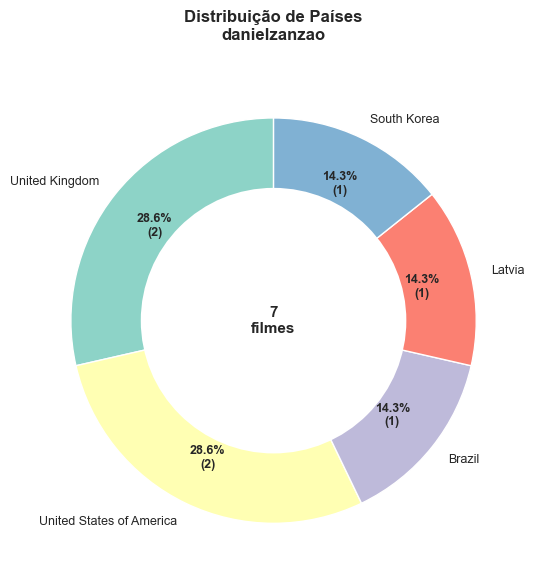


Análise de países para danielzanzao:
   Total de filmes: 7
   Países únicos: 5

  Detalhamento completo:
   United Kingdom           :  2 filmes ( 28.6%) █████
   United States of America :  2 filmes ( 28.6%) █████
   Brazil                   :  1 filmes ( 14.3%) ██
   Latvia                   :  1 filmes ( 14.3%) ██
   South Korea              :  1 filmes ( 14.3%) ██




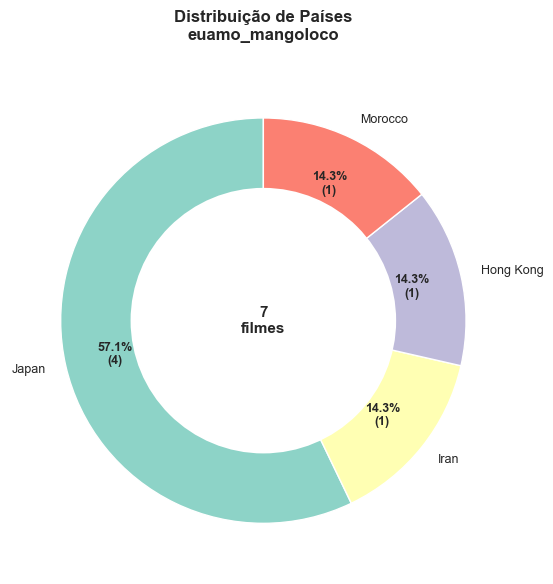


Análise de países para euamo_mangoloco:
   Total de filmes: 7
   Países únicos: 4

  Detalhamento completo:
   Japan                    :  4 filmes ( 57.1%) ███████████
   Iran                     :  1 filmes ( 14.3%) ██
   Hong Kong                :  1 filmes ( 14.3%) ██
   Morocco                  :  1 filmes ( 14.3%) ██




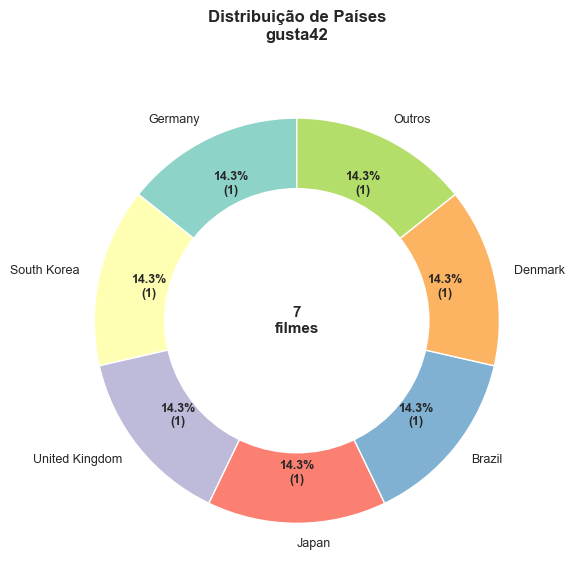


Análise de países para gusta42:
   Total de filmes: 7
   Países únicos: 7

  Detalhamento completo:
   Germany                  :  1 filmes ( 14.3%) ██
   South Korea              :  1 filmes ( 14.3%) ██
   United Kingdom           :  1 filmes ( 14.3%) ██
   Japan                    :  1 filmes ( 14.3%) ██
   Brazil                   :  1 filmes ( 14.3%) ██
   Denmark                  :  1 filmes ( 14.3%) ██
   United States of America :  1 filmes ( 14.3%) ██




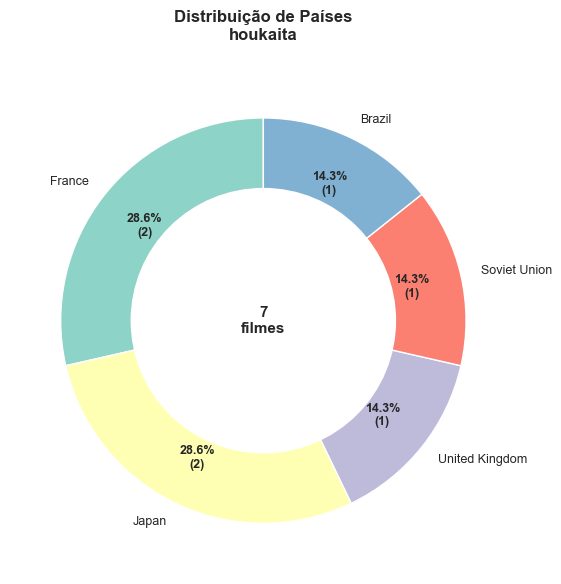


Análise de países para houkaita:
   Total de filmes: 7
   Países únicos: 5

  Detalhamento completo:
   France                   :  2 filmes ( 28.6%) █████
   Japan                    :  2 filmes ( 28.6%) █████
   United Kingdom           :  1 filmes ( 14.3%) ██
   Soviet Union             :  1 filmes ( 14.3%) ██
   Brazil                   :  1 filmes ( 14.3%) ██




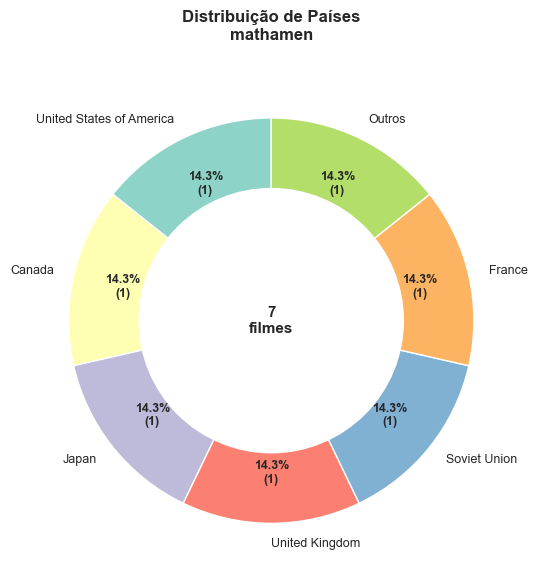


Análise de países para mathamen:
   Total de filmes: 7
   Países únicos: 7

  Detalhamento completo:
   United States of America :  1 filmes ( 14.3%) ██
   Canada                   :  1 filmes ( 14.3%) ██
   Japan                    :  1 filmes ( 14.3%) ██
   United Kingdom           :  1 filmes ( 14.3%) ██
   Soviet Union             :  1 filmes ( 14.3%) ██
   France                   :  1 filmes ( 14.3%) ██
   Hungary                  :  1 filmes ( 14.3%) ██




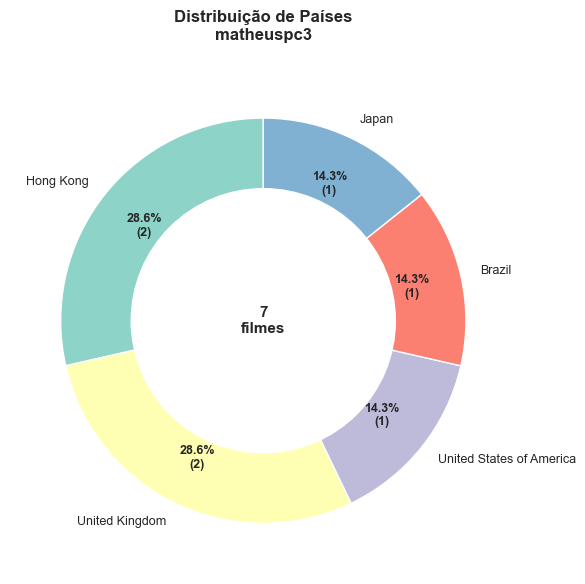


Análise de países para matheuspc3:
   Total de filmes: 7
   Países únicos: 5

  Detalhamento completo:
   Hong Kong                :  2 filmes ( 28.6%) █████
   United Kingdom           :  2 filmes ( 28.6%) █████
   United States of America :  1 filmes ( 14.3%) ██
   Brazil                   :  1 filmes ( 14.3%) ██
   Japan                    :  1 filmes ( 14.3%) ██




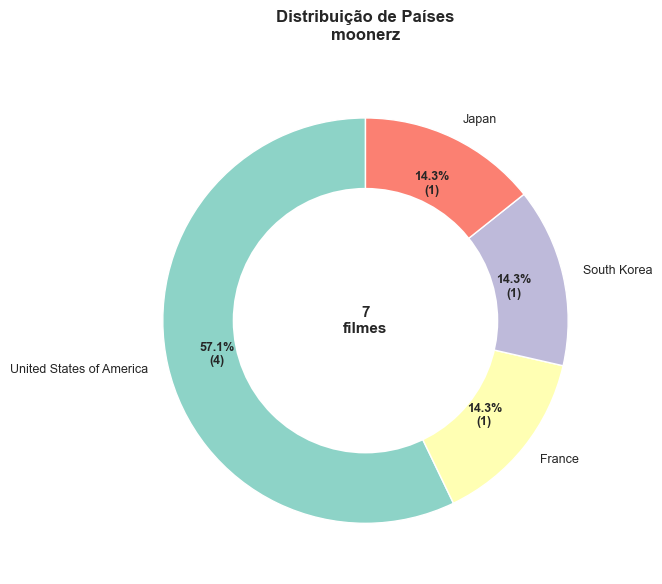


Análise de países para moonerz:
   Total de filmes: 7
   Países únicos: 4

  Detalhamento completo:
   United States of America :  4 filmes ( 57.1%) ███████████
   France                   :  1 filmes ( 14.3%) ██
   South Korea              :  1 filmes ( 14.3%) ██
   Japan                    :  1 filmes ( 14.3%) ██




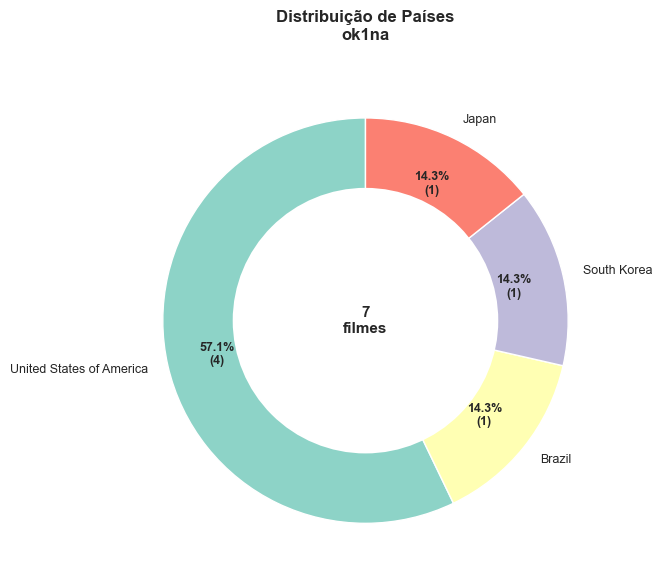


Análise de países para ok1na:
   Total de filmes: 7
   Países únicos: 4

  Detalhamento completo:
   United States of America :  4 filmes ( 57.1%) ███████████
   Brazil                   :  1 filmes ( 14.3%) ██
   South Korea              :  1 filmes ( 14.3%) ██
   Japan                    :  1 filmes ( 14.3%) ██




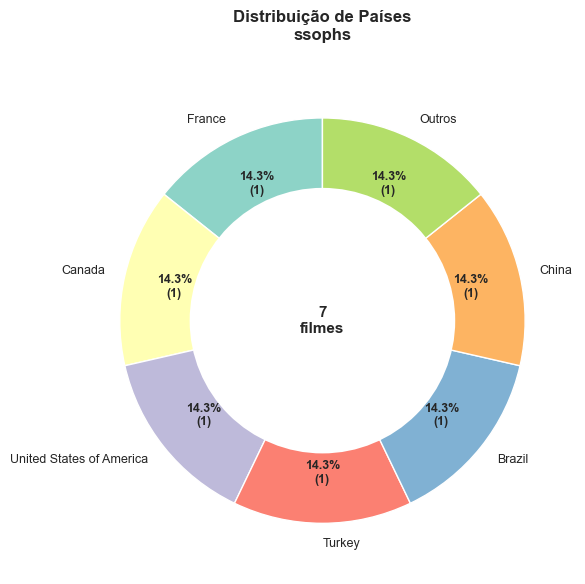


Análise de países para ssophs:
   Total de filmes: 7
   Países únicos: 7

  Detalhamento completo:
   France                   :  1 filmes ( 14.3%) ██
   Canada                   :  1 filmes ( 14.3%) ██
   United States of America :  1 filmes ( 14.3%) ██
   Turkey                   :  1 filmes ( 14.3%) ██
   Brazil                   :  1 filmes ( 14.3%) ██
   China                    :  1 filmes ( 14.3%) ██
   Austria                  :  1 filmes ( 14.3%) ██




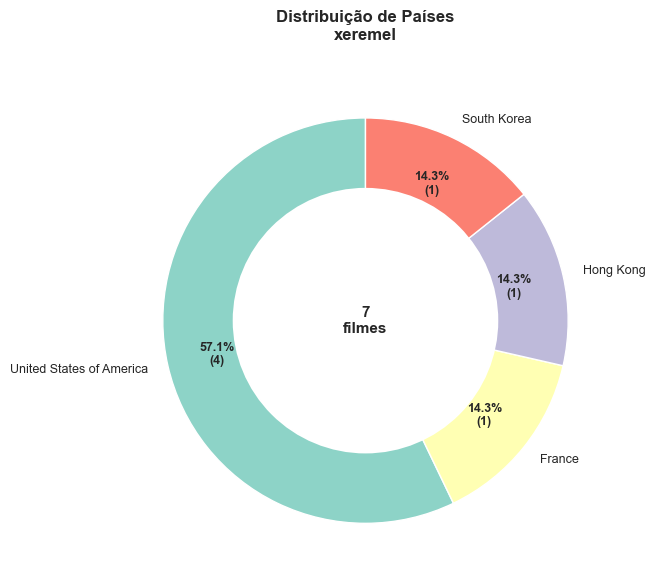


Análise de países para xeremel:
   Total de filmes: 7
   Países únicos: 4

  Detalhamento completo:
   United States of America :  4 filmes ( 57.1%) ███████████
   France                   :  1 filmes ( 14.3%) ██
   Hong Kong                :  1 filmes ( 14.3%) ██
   South Korea              :  1 filmes ( 14.3%) ██




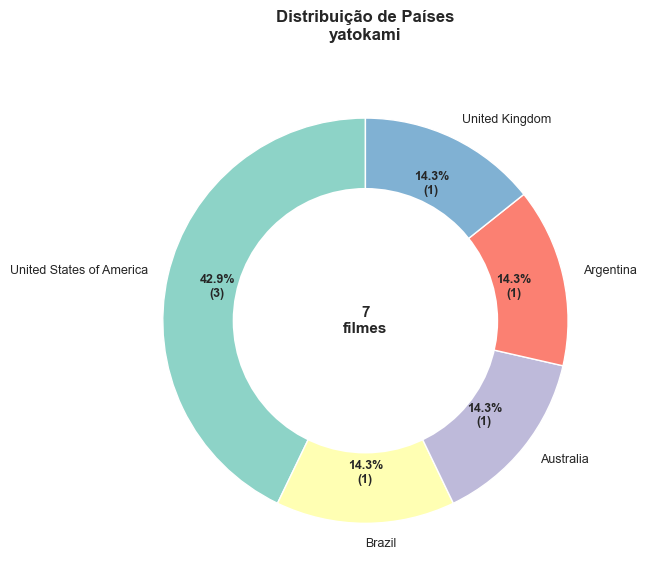


Análise de países para yatokami:
   Total de filmes: 7
   Países únicos: 5

  Detalhamento completo:
   United States of America :  3 filmes ( 42.9%) ████████
   Brazil                   :  1 filmes ( 14.3%) ██
   Australia                :  1 filmes ( 14.3%) ██
   Argentina                :  1 filmes ( 14.3%) ██
   United Kingdom           :  1 filmes ( 14.3%) ██




In [12]:
# PRIMEIRO: Explodir TANTO países QUANTO participantes
df_expandido = df.assign(pais=df['pais'].str.split(', ')).explode('pais')

# Explodir também os participantes (CRÍTICO!)
df_expandido['assistido_por'] = df_expandido['assistido_por'].str.split(', ')
df_expandido = df_expandido.explode('assistido_por')

# Remover valores vazios
df_expandido = df_expandido[df_expandido['assistido_por'].notna()]
df_expandido = df_expandido[df_expandido['assistido_por'] != '']
df_expandido = df_expandido[df_expandido['pais'].notna()]
df_expandido = df_expandido[df_expandido['pais'] != '']

# Agrupar por participante
paises_por_participante = df_expandido.groupby('assistido_por')['pais'].apply(list).to_dict()

## Função melhorada para plotar gráfico (SEM "Outros")
def plot_paises_participante(participante, paises, max_paises=6):
    """
    Plota gráfico de pizza para países assistidos por um participante
    max_paises: número máximo de países a mostrar (o resto vai para "Outros")
    """
    # Contar ocorrências de cada país
    contagem = Counter(paises)
    total_filmes = sum(contagem.values())
    
    # Se tiver poucos países, mostra todos
    if len(contagem) <= max_paises:
        dados = dict(contagem.most_common())
    else:
        # Pega os top N países
        paises_top = [p[0] for p in contagem.most_common(max_paises)]
        dados = {}
        for p in paises_top:
            dados[p] = contagem[p]
        
        # Adiciona "Outros" apenas se fizer sentido
        outros_total = sum(contagem[p] for p in contagem if p not in paises_top)
        if outros_total > 0:
            dados['Outros'] = outros_total
    
    # Criar gráfico de pizza
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Cores personalizadas (evitar "pastel" que pode ser muito claro)
    cores = sns.color_palette("Set3", len(dados))
    
    wedges, texts, autotexts = ax.pie(
        dados.values(),
        labels=dados.keys(),
        autopct=lambda p: f'{p:.1f}%\n({int(round(p/100.*total_filmes))})',
        startangle=90,
        colors=cores,
        textprops={'fontsize': 9},
        pctdistance=0.75
    )
    
    # Melhorar legibilidade
    plt.setp(autotexts, size=9, weight="bold")
    plt.setp(texts, size=9)
    
    # Adicionar círculo central para estilo 'donut'
    centre_circle = plt.Circle((0,0), 0.65, fc='white', linewidth=1.5)
    fig.gca().add_artist(centre_circle)
    
    # Adicionar total no centro
    ax.text(0, 0, f'{total_filmes}\nfilmes', 
            ha='center', va='center', fontsize=11, fontweight='bold')
    
    ax.set_title(f'Distribuição de Países\n{participante}', 
                 pad=20, fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Listar países únicos (para referência)
    print(f"\nAnálise de países para {participante}:")
    print(f"   Total de filmes: {total_filmes}")
    print(f"   Países únicos: {len(contagem)}")
    print(f"\n  Detalhamento completo:")
    for pais, qtd in contagem.most_common():
        percentual = (qtd / total_filmes) * 100
        barra = "█" * int(percentual / 5)  # Barra visual
        print(f"   {pais:25}: {qtd:2} filmes ({percentual:5.1f}%) {barra}")
    print("\n" + "="*60 + "\n")

## Gerar gráficos para cada participante
print("="*60)
print("GRÁFICOS DE PAÍSES POR PARTICIPANTE".center(60))
print("="*60)
print()

for participante, paises in paises_por_participante.items():
    plot_paises_participante(participante, paises)